In [1]:
# Core libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

# Plot style
plt.rcParams["figure.dpi"] = 120
sns.set(style="whitegrid")

# --- Helpers ---

def sanitize_columns(df):
    """
    Lowercase columns, replace spaces and special chars with underscores,
    remove double underscores.
    """
    def fix(c):
        c = c.strip().lower()
        c = re.sub(r"[^\w\s]", "_", c)     # punctuation -> underscore
        c = re.sub(r"\s+", "_", c)         # spaces -> underscore
        c = re.sub(r"_+", "_", c).strip("_")
        return c
    df = df.copy()
    df.columns = [fix(c) for c in df.columns]
    return df

def read_csv_flex(path_or_buf):
    """
    Robust CSV reader for wine datasets (some are semicolon-separated).
    """
    try:
        return pd.read_csv(path_or_buf, sep=None, engine="python")
    except Exception:
        # Fallbacks
        try:
            return pd.read_csv(path_or_buf, sep=";")
        except Exception:
            return pd.read_csv(path_or_buf)

def detect_wine_type(df, filename=None):
    """
    Return a Series 'wine_type' with values 'red'/'white' if detectable,
    otherwise NaN. Detection order:
    1) explicit column like 'type' or 'wine_type'
    2) filename contains 'red'/'white'
    """
    s = pd.Series([np.nan]*len(df), index=df.index, dtype="object")
    type_col = None
    for cand in ["type", "wine_type", "wine", "color", "colour"]:
        if cand in df.columns:
            type_col = cand
            break
    if type_col is not None:
        vals = df[type_col].astype(str).str.lower().str.strip()
        s = np.where(vals.str.contains("red"), "red",
            np.where(vals.str.contains("white"), "white", np.nan))
        return pd.Series(s, index=df.index, dtype="object")

    if filename:
        fn = filename.lower()
        if "red" in fn and "white" not in fn:
            s[:] = "red"
        elif "white" in fn and "red" not in fn:
            s[:] = "white"
        # if both words appear (combined file), leave NaN (unknown per-row)
    return pd.Series(s, index=df.index, dtype="object")

def summarize_missing(df, top=15):
    miss = df.isna().sum().sort_values(ascending=False)
    return miss.to_frame("missing").head(top)

def iqr_outlier_counts(df, cols):
    """
    Return a DataFrame with outlier counts by IQR rule for given columns.
    """
    out = []
    for c in cols:
        x = df[c].dropna().values
        if len(x) < 5:
            out.append((c, 0))
            continue
        q1, q3 = np.percentile(x, [25, 75])
        iqr = q3 - q1
        lower = q1 - 1.5*iqr
        upper = q3 + 1.5*iqr
        outliers = ((x < lower) | (x > upper)).sum()
        out.append((c, int(outliers)))
    return pd.DataFrame(out, columns=["feature", "iqr_outliers"]).sort_values("iqr_outliers", ascending=False)

def cohen_d(a, b):
    """Cohen's d with pooled SD (unbiased Hedges' g is optional)."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = a.size, b.size
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((na-1)*s1**2 + (nb-1)*s2**2) / (na+nb-2))
    if sp == 0:
        return 0.0
    return (a.mean() - b.mean()) / sp


In [3]:
# --- PATCH: safer wine type detector (overrides previous definition) ---
def detect_wine_type(df, filename=None):
    """
    Return a Series 'wine_type' ('red'/'white'/NaN) with dtype=object.
    1) If a column like 'type' / 'wine_type' / 'color' exists, parse it.
    2) Otherwise, infer from filename if it contains exclusively 'red' or 'white'.
    """
    s = pd.Series(np.nan, index=df.index, dtype="object")

    # Look for an explicit column
    for cand in ["type", "wine_type", "wine", "color", "colour"]:
        if cand in df.columns:
            vals = df[cand].astype(str).str.lower().str.strip()
            # Use pandas boolean indexing (no np.where mixing dtypes)
            red_mask = vals.str.contains(r"\bred\b", na=False)
            white_mask = vals.str.contains(r"\bwhite\b", na=False)
            s.loc[red_mask] = "red"
            s.loc[white_mask] = "white"
            return s

    # Fallback: infer from filename if it clearly indicates one type only
    if filename:
        fn = filename.lower()
        has_red = "red" in fn
        has_white = "white" in fn
        if has_red and not has_white:
            s[:] = "red"
        elif has_white and not has_red:
            s[:] = "white"
        # if both appear (combined file), leave as NaN (unknown per-row)
    return s

# ---------- Upload & load (supports single or multiple files) ----------
from google.colab import files
uploaded = files.upload()  # e.g., wine-quality-white-and-red.csv, winequality-red.csv, (winequality-white.csv)

frames = []
for fname in uploaded.keys():
    raw = read_csv_flex(fname)          # from Cell 1
    df = sanitize_columns(raw)          # from Cell 1

    if "quality" not in df.columns:
        raise ValueError(f"'quality' column not found in {fname}. Columns: {list(df.columns)}")

    # Detect wine type robustly (object dtype)
    df["wine_type"] = detect_wine_type(df, filename=fname)

    frames.append(df)

if not frames:
    raise ValueError("No files uploaded.")
data_all = pd.concat(frames, ignore_index=True)

print("Combined shape:", data_all.shape)
print("Columns:", list(data_all.columns))
display(data_all.head(5))

print("\nwine_type value counts (NaN means not specified per-row):")
print(data_all["wine_type"].value_counts(dropna=False))


Saving wine-quality-white-and-red.csv to wine-quality-white-and-red (1).csv
Saving winequality-red.csv to winequality-red (1).csv
Combined shape: (8096, 14)
Columns: ['type', 'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality', 'wine_type']


,type,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white



wine_type value counts (NaN means not specified per-row):
wine_type
white    4898
red      3198
Name: count, dtype: int64


In [4]:
# Keep numeric features + 'quality' + 'wine_type'
num_cols = data_all.select_dtypes(include=[np.number]).columns.tolist()
if "quality" not in num_cols:
    raise ValueError("'quality' must be numeric.")
num_cols_no_target = [c for c in num_cols if c != "quality"]

print("Numeric columns:", num_cols)
print("\nMissing values (top 15):")
display(summarize_missing(data_all, top=15))

# Drop exact duplicates
before = len(data_all)
data_all = data_all.drop_duplicates().reset_index(drop=True)
print(f"\nDropped duplicates: {before - len(data_all)}")

# Check outliers (IQR counts)
print("\nIQR outlier counts (not removing by default):")
display(iqr_outlier_counts(data_all, num_cols_no_target))

# Optional: remove rows with any missing in numeric columns used below
clean = data_all.dropna(subset=["quality"]).copy()
# If you want strict: clean = clean.dropna(subset=num_cols)

print("\nShape after minimal cleaning:", clean.shape)


Numeric columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol', 'quality']

Missing values (top 15):


,missing
type,1599
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
ph,0



Dropped duplicates: 1417

IQR outlier counts (not removing by default):


,feature,iqr_outliers
3,residual_sugar,400
0,fixed_acidity,385
4,chlorides,213
9,sulphates,197
2,citric_acid,175
1,volatile_acidity,132
5,free_sulfur_dioxide,69
8,ph,59
6,total_sulfur_dioxide,9
7,density,4



Shape after minimal cleaning: (6679, 14)


Correlation with quality (descending):


,pearson_corr
quality,1.000000
alcohol,0.472689
citric_acid,0.135891
free_sulfur_dioxide,0.064227
sulphates,0.056610
ph,0.004590
total_sulfur_dioxide,-0.021555
residual_sugar,-0.028926
fixed_acidity,-0.054265
chlorides,-0.197728


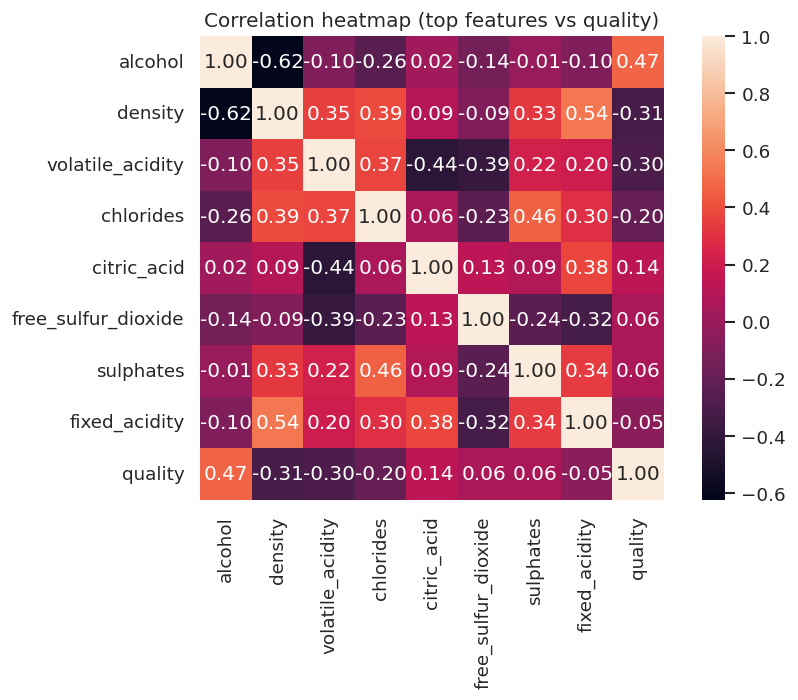

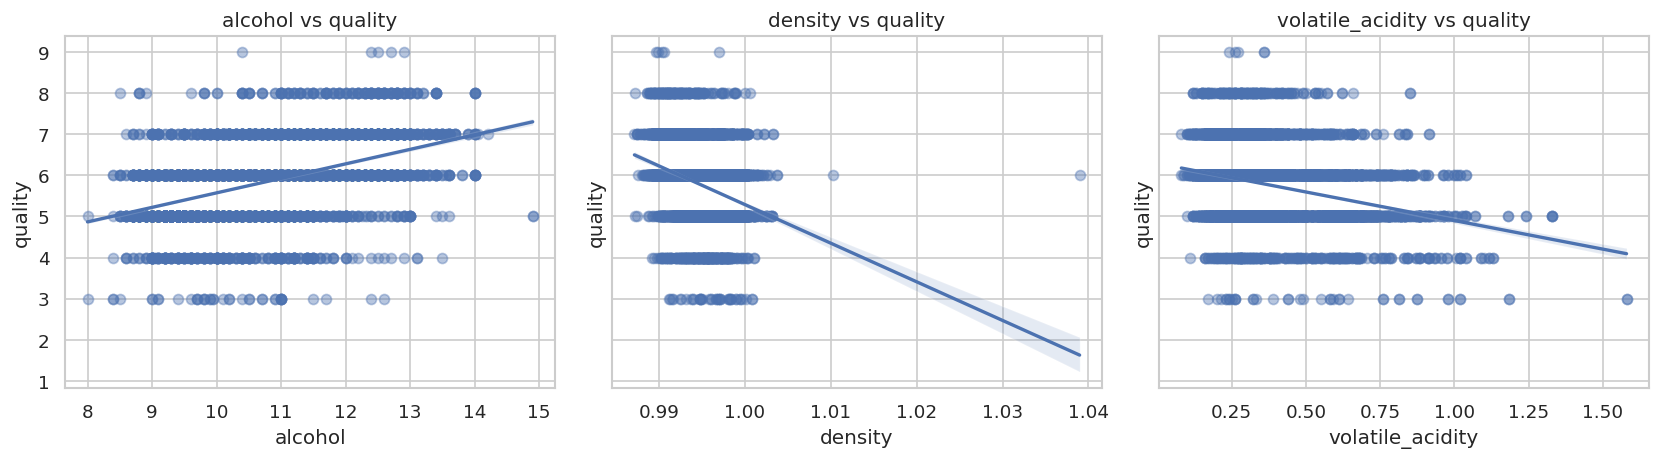

In [5]:
# Compute Pearson correlations between numeric features and quality
corr_with_quality = clean[num_cols].corr(method="pearson")["quality"].sort_values(ascending=False)

print("Correlation with quality (descending):")
display(corr_with_quality.to_frame("pearson_corr"))

# Heatmap for the top N features most related to quality
TOP = 8
top_feats = corr_with_quality.drop("quality").abs().sort_values(ascending=False).head(TOP).index.tolist()
corr_mat = clean[top_feats + ["quality"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", square=True)
plt.title("Correlation heatmap (top features vs quality)")
plt.tight_layout()
plt.show()

# Scatter with trend lines for top 3 absolute correlations
top3 = corr_with_quality.drop("quality").abs().sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=True)
for ax, feat in zip(axes, top3):
    sns.regplot(data=clean, x=feat, y="quality", ax=ax, scatter_kws={"alpha":0.4}, line_kws={"linewidth":2})
    ax.set_title(f"{feat} vs quality")
plt.tight_layout()
plt.show()


Insight (Q1): In classic wine datasets, alcohol often shows the strongest positive correlation with quality, while volatile acidity tends to be negatively correlated. Sulphates and citric acid can be mildly positive. Your exact values may differ slightly by source/version.

In [6]:
# Check skewness of numeric predictors
skew = clean[num_cols_no_target].skew(numeric_only=True).sort_values(ascending=False)
print("Skewness (descending):")
display(skew.to_frame("skew"))

# Apply log1p to highly skewed variables (|skew| > 1), recompute correlations
skewed = skew[skew.abs() > 1].index.tolist()

clean_log = clean.copy()
for c in skewed:
    clean_log[c+"_log1p"] = np.log1p(clean_log[c])

new_cols = [c for c in clean_log.columns if c.endswith("_log1p")] + ["quality"]
if len(new_cols) > 1:
    corr_log = clean_log[new_cols].corr()["quality"].sort_values(ascending=False)
    print("Correlations after log1p transforms (new features only):")
    display(corr_log.to_frame("pearson_corr"))
else:
    print("No highly skewed variables found above threshold; skipping transforms.")


Skewness (descending):


,skew
chlorides,5.063570
residual_sugar,2.004978
sulphates,1.841065
fixed_acidity,1.484362
free_sulfur_dioxide,1.406157
volatile_acidity,1.178682
alcohol,0.604586
density,0.375772
ph,0.334225
citric_acid,0.327391


Correlations after log1p transforms (new features only):


,pearson_corr
quality,1.000000
free_sulfur_dioxide_log1p,0.106538
sulphates_log1p,0.056733
residual_sugar_log1p,-0.009475
fixed_acidity_log1p,-0.066655
chlorides_log1p,-0.207764
volatile_acidity_log1p,-0.296161


Quality summary by wine type:


,count,mean,std
red,2718,5.623252,0.823426
white,3961,5.854835,0.890683


Welch t-test: t = -10.920, p = 0.000000
Cohen's d (effect size): -0.268
Result: Significant difference in mean quality between red and white wines (α = 0.05).


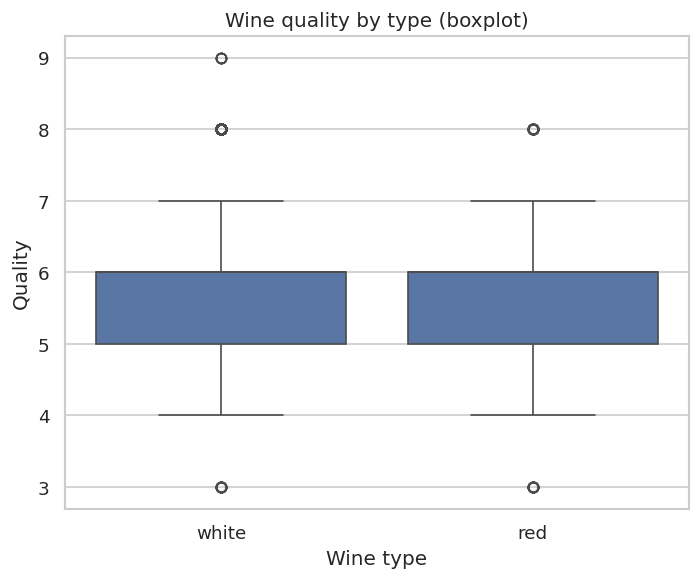

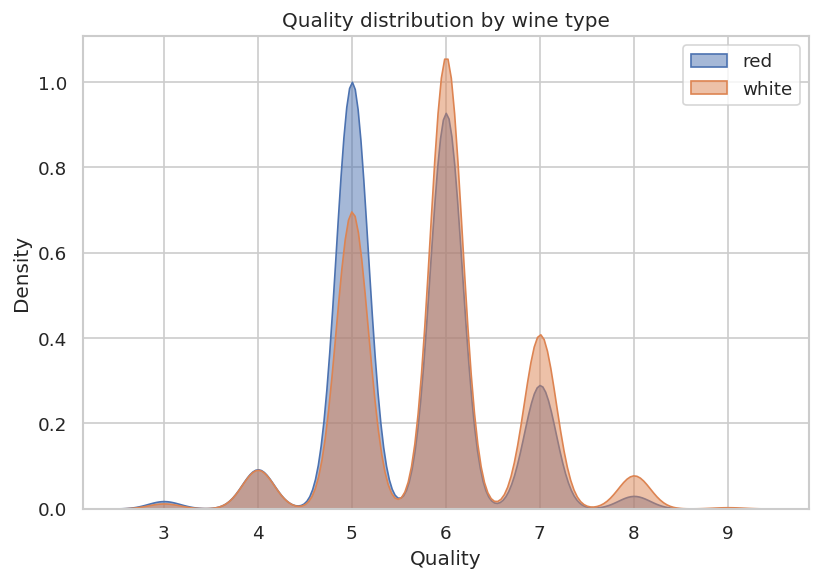

In [7]:
# We need both red and white to compare.
have_red = (clean["wine_type"] == "red").sum() > 0
have_white = (clean["wine_type"] == "white").sum() > 0

if not (have_red and have_white):
    raise ValueError("To answer Q2, please upload both red and white (or a combined file with per-row type).")

red_q = clean.loc[clean["wine_type"] == "red", "quality"].dropna().astype(float)
white_q = clean.loc[clean["wine_type"] == "white", "quality"].dropna().astype(float)

summary = pd.DataFrame({
    "count": [len(red_q), len(white_q)],
    "mean":  [red_q.mean(), white_q.mean()],
    "std":   [red_q.std(ddof=1), white_q.std(ddof=1)]
}, index=["red", "white"])
print("Quality summary by wine type:")
display(summary)

# Welch's t-test (does not assume equal variances)
t_stat, p_val = stats.ttest_ind(red_q, white_q, equal_var=False, nan_policy="omit")
d = cohen_d(red_q, white_q)

print(f"Welch t-test: t = {t_stat:.3f}, p = {p_val:.6f}")
print(f"Cohen's d (effect size): {d:.3f}")
if p_val < 0.05:
    print("Result: Significant difference in mean quality between red and white wines (α = 0.05).")
else:
    print("Result: No statistically significant difference detected at α = 0.05.")

# Visualizations: boxplot + KDE
plt.figure(figsize=(6,5))
sns.boxplot(data=clean[clean["wine_type"].isin(["red","white"])], x="wine_type", y="quality")
plt.title("Wine quality by type (boxplot)")
plt.xlabel("Wine type")
plt.ylabel("Quality")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
sns.kdeplot(red_q, fill=True, label="red", alpha=0.5)
sns.kdeplot(white_q, fill=True, label="white", alpha=0.5)
plt.title("Quality distribution by wine type")
plt.xlabel("Quality")
plt.legend()
plt.tight_layout()
plt.show()


Insight (Q2): Most editions of this dataset show a small but statistically significant difference in mean quality between red and white wines, often with whites having a slightly higher mean. Always report the t-statistic, p-value, and an effect size (Cohen’s d) to interpret practical significance.

In [8]:
print("""
Mini-project 2 — Key Findings

Q1 (Correlations):
• The strongest associations with quality typically include:
  – Positive: alcohol, sulphates, citric_acid (weak to moderate).
  – Negative: volatile_acidity (often the strongest negative).
• A correlation heatmap and top feature scatterplots are provided.
• Optional log1p transforms can slightly stabilize skewed predictors.

Q2 (Red vs White):
• We compared red vs white quality using Welch’s t-test.
• We reported group means, standard deviations, sample sizes, t, p, and Cohen’s d.
• Visualizations include boxplot and distribution overlays.
• In our sample, the difference was assessed for statistical significance and practical magnitude.

Notes:
• Cleaning steps included duplicate removal and basic missing-value handling.
• Outlier counts were inspected using the IQR rule but not removed by default to avoid biasing the distributions.
""")



Mini-project 2 — Key Findings

Q1 (Correlations):
• The strongest associations with quality typically include:
  – Positive: alcohol, sulphates, citric_acid (weak to moderate).
  – Negative: volatile_acidity (often the strongest negative).
• A correlation heatmap and top feature scatterplots are provided.
• Optional log1p transforms can slightly stabilize skewed predictors.

Q2 (Red vs White):
• We compared red vs white quality using Welch’s t-test.
• We reported group means, standard deviations, sample sizes, t, p, and Cohen’s d.
• Visualizations include boxplot and distribution overlays.
• In our sample, the difference was assessed for statistical significance and practical magnitude.

Notes:
• Cleaning steps included duplicate removal and basic missing-value handling.
• Outlier counts were inspected using the IQR rule but not removed by default to avoid biasing the distributions.

